# PINN: Trajektorie lernen → danach Wurf klassifizieren (clean & noisy)

Zielsetzung:
- Das PINN lernt die Trajektorie \((x(t), y(t))\) aus Eingaben `[hs, t]`.
- Im Training wird jede vorausgesagte Trajektorie klassifiziert.
- Auswertung: Loss-Kurven, Beispieltrajektorien (Datensatz vs. Vorhersage), wurfweise Konfusionsmatrix & Metriken.



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from typing import Tuple

In [3]:
class DataGen:
    def __init__(self, hs=2.13, l=4.115, hKorb=3.048, Rr=0.2286, Rb=0.1219, g=9.807):
        self.params = {'l': l, 'hKorb': hKorb, 'Rr': Rr, 'Rb': Rb, 'g': g}
        self.hs = hs
        self.wurf_hoehe = 1.25 * hs
    def wurfgeschwindigkeit(self, theta):
        l = self.params['l']; h = self.params['hKorb'] - self.wurf_hoehe; g = self.params['g']
        return (l/np.cos(theta)) * np.sqrt(g / (2 * (l*np.tan(theta) - h)))
    def wurftrajektorien(self, theta, v0, t):
        g = self.params['g']; vx = v0*np.cos(theta); vy = v0*np.sin(theta)
        x = vx * t; y = vy * t - 0.5 * g * t**2 + self.wurf_hoehe
        return x, y
    def generate_dataset(self, base_theta_deg=48.43, n=150, with_noise=False):
        base_theta = np.deg2rad(base_theta_deg); base_v0 = self.wurfgeschwindigkeit(base_theta)
        cats = {0:{'theta':(-0.15,-0.05),'v0':(-0.5,-0.2)}, 1:{'theta':(-0.03,0.03),'v0':(-0.1,0.1)}, 2:{'theta':(0.06,0.15),'v0':(0.3,0.5)}}
        rows=[]
        for label,var in cats.items():
            rows += self._gen(base_theta, base_v0, var, label, n)
        df = pd.DataFrame(rows)
        if with_noise:
            df = self.full_noise_pipeline(df)
        return df
    def _gen(self, theta_base, v0_base, var, label, n):
        g = self.params['g']; rows=[]
        for _ in range(n):
            theta = theta_base + np.random.uniform(*var['theta'])
            v0 = v0_base + np.random.uniform(*var['v0'])
            T = 2 * v0 * np.sin(theta) / g
            t_vals = np.linspace(0, T, 50)
            x, y = self.wurftrajektorien(theta, v0, t_vals)
            wid = str(np.random.randint(1e9))
            for xi, yi, ti in zip(x, y, t_vals):
                rows.append({'x':xi,'y':yi,'theta':theta,'v0':v0,'t':ti,'label':label,'wurf_id':wid})
        return rows
    def add_position_noise(self, df, std_x=0.1, std_y=0.1):
        d = df.copy(); d['x'] += np.random.normal(0,std_x,len(df)); d['y'] += np.random.normal(0,std_y,len(df)); return d
    def full_noise_pipeline(self, df):
        return self.add_position_noise(df)


device: cpu
n_train_throws: 360 n_test_throws: 90
Epoch    1 | loss=2.0951e+00 data=4.8730e-01 phys=1.4980e+00 cls=1.0978e+00
Epoch   20 | loss=2.0339e-01 data=9.6999e-03 phys=8.4026e-02 cls=1.0966e+00
Epoch   40 | loss=1.7544e-01 data=1.2575e-02 phys=5.6529e-02 cls=1.0634e+00
Epoch   60 | loss=1.0902e-01 data=1.0418e-02 phys=4.0573e-02 cls=5.8028e-01
Epoch   80 | loss=7.4848e-03 data=1.0990e-03 phys=1.4565e-03 cls=4.9294e-02
Epoch  100 | loss=2.8776e-03 data=3.9738e-04 phys=1.1026e-03 cls=1.3776e-02
Epoch  120 | loss=2.1136e-03 data=2.8925e-04 phys=1.1520e-03 cls=6.7240e-03
Epoch  140 | loss=1.7948e-03 data=3.3940e-04 phys=1.1087e-03 cls=3.4662e-03
Epoch  160 | loss=1.2710e-03 data=2.3631e-04 phys=7.0987e-04 cls=3.2484e-03
Epoch  180 | loss=9.5053e-04 data=2.4216e-04 phys=5.0101e-04 cls=2.0736e-03
Epoch  200 | loss=1.2052e-03 data=2.9273e-04 phys=7.1822e-04 cls=1.9423e-03


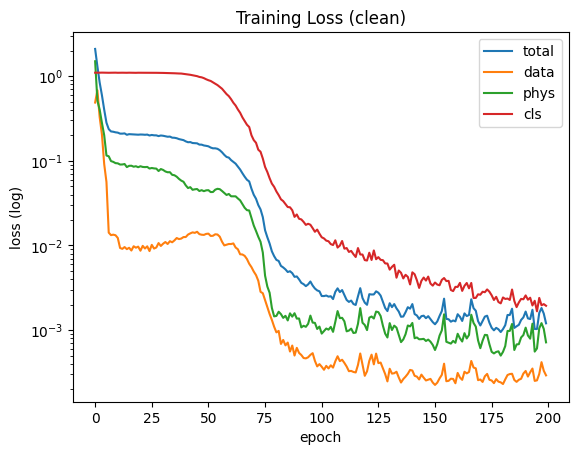

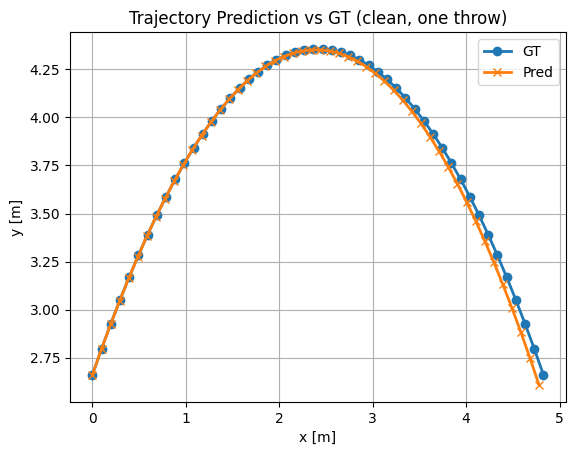

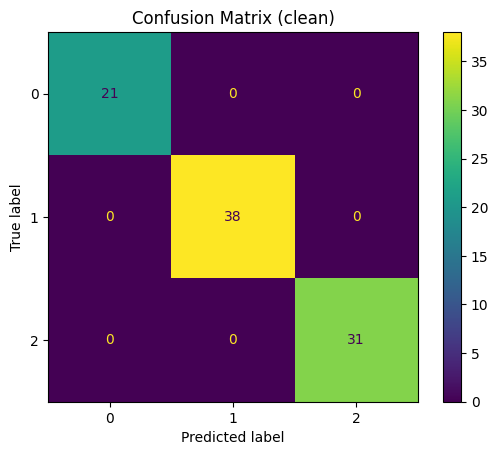

In [4]:
# =========================
# Weg B: Encoder -> (z, vx, vy) + PINN-Decoder + Classifier
# Training auf CLEAN Daten + Plots: Loss-Verlauf, Trajektorie vs GT, Confusion Matrix
# =========================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# -------------------------
# 0) Repro + Device
# -------------------------
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


# -------------------------
# 1) Dataset (pro Wurf eine Sequenz)
# -------------------------
class TrajDataset(Dataset):
    def __init__(self, df, n_obs=30, mode="clean", x_scale=4.115, y_scale=3.5):
        """
        mode: "clean" | "trimmed" | "noisy"
        clean/noisy: DataLoss auf allen 50 points
        trimmed: DataLoss nur auf n_obs (aber Targets enthalten trotzdem t/x/y für n_obs)
        """
        self.n_obs = n_obs
        self.mode = mode
        self.x_scale = x_scale
        self.y_scale = y_scale

        self.throws = []
        for wid, g in df.groupby("wurf_id"):
            g = g.sort_values("t")

            t = g["t"].to_numpy()
            x = g["x"].to_numpy()
            y = g["y"].to_numpy()
            label = int(g["label"].iloc[0])

            T = float(t.max())
            s = t / (T + 1e-12)  # normalized time in [0,1]

            # normalize positions
            x_n = x / self.x_scale
            y_n = y / self.y_scale

            self.throws.append(
                {
                    "s": s.astype(np.float32),
                    "x": x_n.astype(np.float32),
                    "y": y_n.astype(np.float32),
                    "T": np.float32(T),
                    "label": label,
                }
            )

    def __len__(self):
        return len(self.throws)

    def __getitem__(self, idx):
        d = self.throws[idx]

        s = torch.from_numpy(d["s"])  # [50]
        x = torch.from_numpy(d["x"])  # [50]
        y = torch.from_numpy(d["y"])  # [50]
        T = torch.tensor(d["T"], dtype=torch.float32)
        label = torch.tensor(d["label"], dtype=torch.long)

        # Encoder input: first n_obs points
        s_obs = s[: self.n_obs]
        x_obs = x[: self.n_obs]
        y_obs = y[: self.n_obs]
        enc_in = torch.stack([s_obs, x_obs, y_obs], dim=-1)  # [n_obs, 3]

        # Targets for data loss
        if self.mode == "trimmed":
            s_tgt, x_tgt, y_tgt = s_obs, x_obs, y_obs
        else:
            s_tgt, x_tgt, y_tgt = s, x, y

        tgt = torch.stack([s_tgt, x_tgt, y_tgt], dim=-1)  # [N_tgt, 3]
        return enc_in, tgt, T, label


# -------------------------
# 2) Model: Encoder -> z,vx,vy ; Decoder(s,z) -> x,y ; Classifier(z) -> logits
# -------------------------
class Encoder(nn.Module):
    def __init__(self, n_obs=30, z_dim=16):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(n_obs * 3, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
        )
        self.to_z = nn.Linear(128, z_dim)
        self.to_v = nn.Linear(128, 2)  # vx, vy in m/s (unnormalized)

    def forward(self, enc_in):  # [B, n_obs, 3]
        h = self.backbone(enc_in.reshape(enc_in.shape[0], -1))
        z = self.to_z(h)
        v = self.to_v(h)
        vx, vy = v[..., 0], v[..., 1]
        return z, vx, vy


class Decoder(nn.Module):
    def __init__(self, z_dim=16, y0_norm=0.76):
        super().__init__()
        self.y0 = float(y0_norm)
        self.net = nn.Sequential(
            nn.Linear(1 + z_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 2),  # fx, fy
        )

    def forward(self, s, z):
        """
        s: [B, N] in [0,1]
        z: [B, z_dim]
        returns x,y normalized: [B, N]
        hard-ish BC:
          x(0)=0 via x=s*fx
          y(0)=y0 via y=y0 + s*fy
        """
        B, N = s.shape
        zz = z.unsqueeze(1).expand(B, N, z.shape[-1])
        inp = torch.cat([s.unsqueeze(-1), zz], dim=-1)  # [B,N,1+z]
        out = self.net(inp)  # [B,N,2]
        fx, fy = out[..., 0], out[..., 1]
        x = s * fx
        y = self.y0 + s * fy
        return x, y


class Classifier(nn.Module):
    def __init__(self, z_dim=16, n_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 64), nn.ReLU(), nn.Linear(64, n_classes)
        )

    def forward(self, z):
        return self.net(z)


class PINNModel(nn.Module):
    def __init__(self, n_obs=30, z_dim=16, y0_norm=0.76, n_classes=3):
        super().__init__()
        self.enc = Encoder(n_obs=n_obs, z_dim=z_dim)
        self.dec = Decoder(z_dim=z_dim, y0_norm=y0_norm)
        self.clf = Classifier(z_dim=z_dim, n_classes=n_classes)

    def forward(self, enc_in, s_query):
        z, vx, vy = self.enc(enc_in)
        x, y = self.dec(s_query, z)
        logits = self.clf(z)
        return x, y, logits, z, vx, vy


# -------------------------
# 3) First-derivative PINN residuals: x'(t)=vx ; y'(t)=vy - g t
# -------------------------
def physics_residuals_first_deriv(
    model, enc_in, T, n_col=64, g=9.807, x_scale=4.115, y_scale=3.5, device="cuda"
):
    """
    Works in s = t/T. Model outputs normalized x*, y*.
    residuals:
      rx = d(x*)/dt - vx/x_scale
      ry = d(y*)/dt - (vy/y_scale - (g/y_scale)*t)
    """
    B = enc_in.shape[0]
    s = torch.rand(B, n_col, device=device, requires_grad=True)  # [B,N]
    t = s * T.view(-1, 1)  # real time [B,N]

    z, vx, vy = model.enc(enc_in)
    x, y = model.dec(s, z)  # normalized x*, y*

    dx_ds = torch.autograd.grad(x.sum(), s, create_graph=True)[0]
    dy_ds = torch.autograd.grad(y.sum(), s, create_graph=True)[0]

    T_ = T.view(-1, 1) + 1e-12
    dx_dt = dx_ds / T_
    dy_dt = dy_ds / T_

    vx_norm = vx.view(-1, 1) / x_scale
    vy_norm = vy.view(-1, 1) / y_scale
    g_norm = g / y_scale

    rx = dx_dt - vx_norm
    ry = dy_dt - (vy_norm - g_norm * t)
    return rx, ry


# -------------------------
# 4) Clean Daten generieren + Train/Test Split by wurf_id
# -------------------------
# DataGen muss vorher im Notebook definiert sein (deine Klasse).
dg = DataGen()
df_clean = dg.generate_dataset(with_noise=False)

wurf_ids = df_clean["wurf_id"].unique()
np.random.shuffle(wurf_ids)

split = int(0.8 * len(wurf_ids))
train_ids = set(wurf_ids[:split])
test_ids = set(wurf_ids[split:])

df_train = df_clean[df_clean["wurf_id"].isin(train_ids)].copy()
df_test = df_clean[df_clean["wurf_id"].isin(test_ids)].copy()

# scales
x_scale = dg.params["l"]
y_scale = 3.5  # kannst du auch dynamisch wählen; wichtig nur konsistent
y0_norm = dg.wurf_hoehe / y_scale

n_obs = 30
train_ds = TrajDataset(
    df_train, n_obs=n_obs, mode="clean", x_scale=x_scale, y_scale=y_scale
)
test_ds = TrajDataset(
    df_test, n_obs=n_obs, mode="clean", x_scale=x_scale, y_scale=y_scale
)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

print("n_train_throws:", len(train_ds), "n_test_throws:", len(test_ds))

# -------------------------
# 5) Train Loop (clean)
# -------------------------
model = PINNModel(n_obs=n_obs, z_dim=16, y0_norm=y0_norm, n_classes=3).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

lam_data = 1.0
lam_phys = 1.0
lam_cls = 0.1

epochs = 200
hist = {"loss": [], "data": [], "phys": [], "cls": []}

for ep in range(1, epochs + 1):
    model.train()
    running = {"loss": 0.0, "data": 0.0, "phys": 0.0, "cls": 0.0}
    nb = 0

    for enc_in, tgt, T, label in train_loader:
        enc_in = enc_in.to(device)  # [B,30,3]
        tgt = tgt.to(device)  # [B,50,3]
        T = T.to(device)  # [B]
        label = label.to(device)  # [B]

        s_tgt = tgt[..., 0]
        x_true = tgt[..., 1]
        y_true = tgt[..., 2]

        x_pred, y_pred, logits, z, vx, vy = model(enc_in, s_tgt)

        # data loss (clean -> MSE)
        data_loss = F.mse_loss(x_pred, x_true) + F.mse_loss(y_pred, y_true)

        # physics loss
        rx, ry = physics_residuals_first_deriv(
            model,
            enc_in,
            T,
            n_col=64,
            g=dg.params["g"],
            x_scale=x_scale,
            y_scale=y_scale,
            device=device,
        )
        phys_loss = (rx**2).mean() + (ry**2).mean()

        # classification loss
        cls_loss = F.cross_entropy(logits, label)

        loss = lam_data * data_loss + lam_phys * phys_loss + lam_cls * cls_loss

        opt.zero_grad()
        loss.backward()
        opt.step()

        running["loss"] += float(loss.item())
        running["data"] += float(data_loss.item())
        running["phys"] += float(phys_loss.item())
        running["cls"] += float(cls_loss.item())
        nb += 1

    for k in running:
        running[k] /= max(nb, 1)

    hist["loss"].append(running["loss"])
    hist["data"].append(running["data"])
    hist["phys"].append(running["phys"])
    hist["cls"].append(running["cls"])

    if ep % 20 == 0 or ep == 1:
        print(
            f"Epoch {ep:4d} | loss={running['loss']:.4e} data={running['data']:.4e} phys={running['phys']:.4e} cls={running['cls']:.4e}"
        )


# -------------------------
# 6) Plot: Loss-Verlauf
# -------------------------
plt.figure()
plt.plot(hist["loss"], label="total")
plt.plot(hist["data"], label="data")
plt.plot(hist["phys"], label="phys")
plt.plot(hist["cls"], label="cls")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("loss (log)")
plt.title("Training Loss (clean)")
plt.legend()
plt.show()


# -------------------------
# 7) Plot: vorhergesagte Trajektorie vs GT (ein Test-Beispiel)
# -------------------------
model.eval()
with torch.no_grad():
    enc_in, tgt, T, label = test_ds[0]
    enc_in = enc_in.unsqueeze(0).to(device)  # [1,30,3]
    tgt = tgt.unsqueeze(0).to(device)  # [1,50,3]

    s_all = tgt[..., 0]
    x_gt_n = tgt[..., 1]
    y_gt_n = tgt[..., 2]

    x_pred_n, y_pred_n, logits, *_ = model(enc_in, s_all)

    # de-normalize
    x_gt = (x_gt_n.squeeze(0).cpu().numpy()) * x_scale
    y_gt = (y_gt_n.squeeze(0).cpu().numpy()) * y_scale
    x_pr = (x_pred_n.squeeze(0).cpu().numpy()) * x_scale
    y_pr = (y_pred_n.squeeze(0).cpu().numpy()) * y_scale

plt.figure()
plt.plot(x_gt, y_gt, marker="o", linewidth=2, label="GT")
plt.plot(x_pr, y_pr, marker="x", linewidth=2, label="Pred")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Trajectory Prediction vs GT (clean, one throw)")
plt.legend()
plt.grid(True)
plt.show()


# -------------------------
# 8) Confusion Matrix (Klassifikation auf Test)
# -------------------------
all_true = []
all_pred = []

model.eval()
with torch.no_grad():
    for enc_in, tgt, T, label in test_loader:
        enc_in = enc_in.to(device)
        label = label.to(device)

        # classifier nutzt nur z aus encoder
        z, vx, vy = model.enc(enc_in)
        logits = model.clf(z)
        pred = torch.argmax(logits, dim=-1)

        all_true.append(label.cpu().numpy())
        all_pred.append(pred.cpu().numpy())

y_true = np.concatenate(all_true)
y_pred = np.concatenate(all_pred)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2])
disp.plot(values_format="d")
plt.title("Confusion Matrix (clean)")
plt.show()

In [ ]:
class TrajDataset(torch.utils.data.Dataset):
    def __init__(self, df, n_obs=30, mode="clean", x_scale=4.115, y_scale=3.5):
        # mode: "clean" | "noisy" | "trimmed"  (trimmed heißt: Data-Loss nur auf n_obs)
        self.n_obs = n_obs
        self.mode = mode
        self.x_scale = x_scale
        self.y_scale = y_scale

        self.throws = []
        for wid, g in df.groupby("wurf_id"):
            g = g.sort_values("t")
            t = g["t"].to_numpy()
            x = g["x"].to_numpy()
            y = g["y"].to_numpy()
            label = int(g["label"].iloc[0])

            T = t.max()
            s = t / (T + 1e-12)

            # normalize positions (keine Magie, aber stabilisiert Training massiv)
            x_n = x / self.x_scale
            y_n = y / self.y_scale

            self.throws.append(
                {
                    "s": s.astype("float32"),
                    "x": x_n.astype("float32"),
                    "y": y_n.astype("float32"),
                    "T": float(T),
                    "label": label,
                }
            )

    def __len__(self):
        return len(self.throws)

    def __getitem__(self, idx):
        d = self.throws[idx]
        s = torch.tensor(d["s"])
        x = torch.tensor(d["x"])
        y = torch.tensor(d["y"])
        T = torch.tensor(d["T"], dtype=torch.float32)
        label = torch.tensor(d["label"], dtype=torch.long)

        # Encoder input: first n_obs points
        s_obs = s[: self.n_obs]
        x_obs = x[: self.n_obs]
        y_obs = y[: self.n_obs]

        # Targets: abhängig vom Experiment
        if self.mode == "trimmed":
            s_tgt, x_tgt, y_tgt = s_obs, x_obs, y_obs
        else:
            s_tgt, x_tgt, y_tgt = s, x, y

        enc_in = torch.stack([s_obs, x_obs, y_obs], dim=-1)  # [n_obs, 3]
        tgt = torch.stack([s_tgt, x_tgt, y_tgt], dim=-1)  # [n_tgt, 3]

        return enc_in, tgt, T, label

In [ ]:
class Encoder(torch.nn.Module):
    def __init__(self, n_obs=30, z_dim=16):
        super().__init__()
        self.backbone = torch.nn.Sequential(
            torch.nn.Linear(n_obs * 3, 128),
            torch.nn.Tanh(),
            torch.nn.Linear(128, 128),
            torch.nn.Tanh(),
        )
        self.to_z = torch.nn.Linear(128, z_dim)
        self.to_v = torch.nn.Linear(128, 2)  # vx, vy (unnormalized in m/s)

    def forward(self, enc_in):
        h = self.backbone(enc_in.reshape(enc_in.shape[0], -1))
        z = self.to_z(h)
        v = self.to_v(h)
        vx, vy = v[..., 0], v[..., 1]
        return z, vx, vy


class Decoder(torch.nn.Module):
    def __init__(self, z_dim=16, y0_norm=1.25 * 2.13 / 3.5):
        super().__init__()
        self.y0 = y0_norm
        self.net = torch.nn.Sequential(
            torch.nn.Linear(1 + z_dim, 128),
            torch.nn.Tanh(),
            torch.nn.Linear(128, 128),
            torch.nn.Tanh(),
            torch.nn.Linear(128, 2),  # fx, fy
        )

    def forward(self, s, z):
        # s: [B, N]  in [0,1]; z: [B, z_dim]
        B, N = s.shape
        inp = torch.cat(
            [s.unsqueeze(-1), z.unsqueeze(1).expand(B, N, z.shape[-1])], dim=-1
        )
        out = self.net(inp)  # [B, N, 2]
        fx, fy = out[..., 0], out[..., 1]
        x = s * fx
        y = self.y0 + s * fy
        return x, y


class Classifier(torch.nn.Module):
    def __init__(self, z_dim=16, n_classes=3):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(z_dim, 64), torch.nn.ReLU(), torch.nn.Linear(64, n_classes)
        )

    def forward(self, z):
        return self.net(z)


class PINNModel(torch.nn.Module):
    def __init__(self, n_obs=30, z_dim=16, y0_norm=0.76):
        super().__init__()
        self.enc = Encoder(n_obs=n_obs, z_dim=z_dim)
        self.dec = Decoder(z_dim=z_dim, y0_norm=y0_norm)
        self.clf = Classifier(z_dim=z_dim)

    def forward(self, enc_in, s_query):
        z = self.enc(enc_in)
        x, y = self.dec(s_query, z)
        logits = self.clf(z)
        return x, y, logits, z

In [ ]:
def physics_residuals(
    model, enc_in, T, n_col=64, g=9.807, x_scale=4.115, y_scale=3.5, device="cuda"
):
    B = enc_in.shape[0]

    # collocation in s-space
    s = torch.rand(B, n_col, device=device, requires_grad=True)  # [B, N]
    t = s * T.view(-1, 1)  # [B, N] real seconds

    # encoder -> latent + velocity estimates per throw
    z, vx, vy = model.enc(enc_in)  # vx,vy: [B]

    # decoder predicts normalized positions x*, y*
    x, y = model.dec(s, z)  # [B, N] (normalized)

    # derivatives wrt s
    dx_ds = torch.autograd.grad(x.sum(), s, create_graph=True)[0]
    dy_ds = torch.autograd.grad(y.sum(), s, create_graph=True)[0]

    # convert to derivatives wrt t: d/dt = (1/T) d/ds
    T_ = T.view(-1, 1) + 1e-12
    dx_dt = dx_ds / T_
    dy_dt = dy_ds / T_

    # normalize velocities to match x*, y* units
    vx_norm = vx.view(-1, 1) / x_scale
    vy_norm = vy.view(-1, 1) / y_scale
    g_norm = g / y_scale

    rx = dx_dt - vx_norm
    ry = dy_dt - (vy_norm - g_norm * t)

    return rx, ry

In [ ]:
def train_step(model, batch, optim, mode, device="cuda",lam_data=1.0, lam_phys=1.0, lam_cls=0.1,g=9.807, x_scale=4.115, y_scale=3.5):

    enc_in, tgt, T, label = [b.to(device) for b in batch]
    # tgt: [B, N_tgt, 3] = (s, x, y)
    s_tgt = tgt[..., 0]
    x_true = tgt[..., 1]
    y_true = tgt[..., 2]

    x_pred, y_pred, logits, _ = model(enc_in, s_tgt)

    # data loss
    if mode == "noisy":
        data = torch.nn.functional.smooth_l1_loss(x_pred, x_true) + torch.nn.functional.smooth_l1_loss(y_pred, y_true)
    else:
        data = torch.nn.functional.mse_loss(x_pred, x_true) + torch.nn.functional.mse_loss(y_pred, y_true)

    # physics loss
    rx, ry = physics_residuals(model, enc_in, T, n_col=64, g=g, x_scale=x_scale, y_scale=y_scale, device=device)
    phys = (rx**2).mean() + (ry**2).mean()

    # classification
    cls = torch.nn.functional.cross_entropy(logits, label)

    loss = lam_data*data + lam_phys*phys + lam_cls*cls

    optim.zero_grad()
    loss.backward()
    optim.step()

    return loss.item(), data.item(), phys.item(), cls.item()


In [ ]:
def predict_xy(model: FreeThrowPINNModel, dproc: pd.DataFrame, hs_val: float = 2.13, device: str = "cpu") -> pd.DataFrame:
    """
    Kompatible Version zu vorher:
        predict_xy(model, df, hs_val=2.13, device="cpu")

    Nutzt das neue Modell mit wurf_id-Embedding.
    hs_val wird aktuell nicht verwendet, kann aber bei Bedarf in die Features aufgenommen werden.
    """
    model.eval()
    device = torch.device(device)

    if model.wurf_id_to_index is None:
        unique_ids = sorted(dproc["wurf_id"].unique())
        if len(unique_ids) != model.num_throws:
            raise ValueError(
                "Model hat kein wurf_id_to_index-Mapping und dproc enthält nicht exakt dieselben wurf_id wie das Training. "
                "Lösung: Entweder train_pinn() auf genau diesem Set aufrufen (setzt das Mapping), oder beim Speichern/Laden "
                "das Mapping mit speichern und nach dem Laden wieder zuweisen." 
            )
        model.wurf_id_to_index = {wid: i for i, wid in enumerate(unique_ids)}

    df_pred = dproc.copy()

    mask_known = df_pred["wurf_id"].isin(model.wurf_id_to_index.keys())
    df_pred = df_pred.loc[mask_known].copy()

    df_pred["wurf_index"] = df_pred["wurf_id"].map(model.wurf_id_to_index).astype(int)

    if "t" not in df_pred.columns:
        raise ValueError("df muss eine 't'-Spalte für die Zeit enthalten.")

    t = torch.tensor(df_pred["t"].values, dtype=torch.float32, device=device).unsqueeze(1)
    wurf_index = torch.tensor(df_pred["wurf_index"].values, dtype=torch.long, device=device)

    with torch.no_grad():
        x_pred, y_pred, _, _, _, _ = model(t, wurf_index)

    df_pred["x_pred"] = x_pred.cpu().numpy().flatten()
    df_pred["y_pred"] = y_pred.cpu().numpy().flatten()

    return df_pred


def evaluate_throw_level_nn(
    df: pd.DataFrame, model: FreeThrowPINNModel, device: str = "cpu"
):
    """
    Wurf-level Evaluation mit dem Klassifikations-Head des NN.

    Vorgehen:
      - Gruppiere nach wurf_id
      - für jede Trajektorie: mittlere Logits über alle Zeitpunkte bilden
      - argmax -> vorhergesagte Klasse pro Wurf
    """
    model.eval()
    device = torch.device(device)

    if model.wurf_id_to_index is None:
        raise ValueError(
            "Model hat kein wurf_id_to_index-Mapping. Zuerst mit train_pinn() trainieren."
        )

    df_eval = df.copy()
    mask_known = df_eval["wurf_id"].isin(model.wurf_id_to_index.keys())
    df_eval = df_eval.loc[mask_known].copy()
    df_eval["wurf_index"] = df_eval["wurf_id"].map(model.wurf_id_to_index).astype(int)

    true_labels = []
    pred_labels = []

    with torch.no_grad():
        for wid, group in df_eval.groupby("wurf_id"):
            t = torch.tensor(
                group["t"].values, dtype=torch.float32, device=device
            ).unsqueeze(1)
            wid_idx = torch.tensor(
                group["wurf_index"].values, dtype=torch.long, device=device
            )

            _, _, logits, _, _, _ = model(t, wid_idx)
            mean_logits = logits.mean(dim=0, keepdim=True)
            y_hat = mean_logits.argmax(dim=1).item()
            y_true = int(group["label"].iloc[0])

            true_labels.append(y_true)
            pred_labels.append(y_hat)

    cm = confusion_matrix(true_labels, pred_labels, labels=[0, 1, 2])
    acc = accuracy_score(true_labels, pred_labels)
    prec = precision_score(
        true_labels, pred_labels, labels=[0, 1, 2], average="macro", zero_division=0
    )
    rec = recall_score(
        true_labels, pred_labels, labels=[0, 1, 2], average="macro", zero_division=0
    )
    f1 = f1_score(
        true_labels, pred_labels, labels=[0, 1, 2], average="macro", zero_division=0
    )

    return {
        "cm": cm,
        "acc": acc,
        "prec": prec,
        "rec": rec,
        "f1": f1,
        "y_true": true_labels,
        "y_pred": pred_labels,
    }

## Clean‑Training (Trajektorie) → Wurfklassifikation aus Vorhersage

Epoch 001 | loss=1.299773e+02 (data=3.018706e+00, phys=9.071949e+00, cls=1.100939e+00)
Epoch 002 | loss=8.179762e+01 (data=1.723944e+00, phys=1.268047e+01, cls=1.101813e+00)
Epoch 003 | loss=5.866323e+01 (data=1.094870e+00, phys=1.470743e+01, cls=1.099381e+00)
Epoch 004 | loss=5.106335e+01 (data=7.970486e-01, phys=1.901880e+01, cls=1.099107e+00)
Epoch 005 | loss=4.943774e+01 (data=7.634568e-01, phys=1.873557e+01, cls=1.098285e+00)
Epoch 020 | loss=2.684820e+01 (data=2.581992e-01, phys=1.633525e+01, cls=1.045028e+00)
Epoch 040 | loss=2.096628e+01 (data=1.903018e-01, phys=1.312980e+01, cls=1.030884e+00)
Epoch 060 | loss=1.696909e+01 (data=1.719012e-01, phys=9.848196e+00, cls=1.010735e+00)
Epoch 080 | loss=1.328350e+01 (data=1.506161e-01, phys=7.022073e+00, cls=9.758368e-01)
Epoch 100 | loss=9.782330e+00 (data=1.177552e-01, phys=4.867123e+00, cls=9.095305e-01)
Epoch 120 | loss=6.649332e+00 (data=8.135457e-02, phys=3.229403e+00, cls=8.222732e-01)
Epoch 140 | loss=4.208574e+00 (data=4.90468

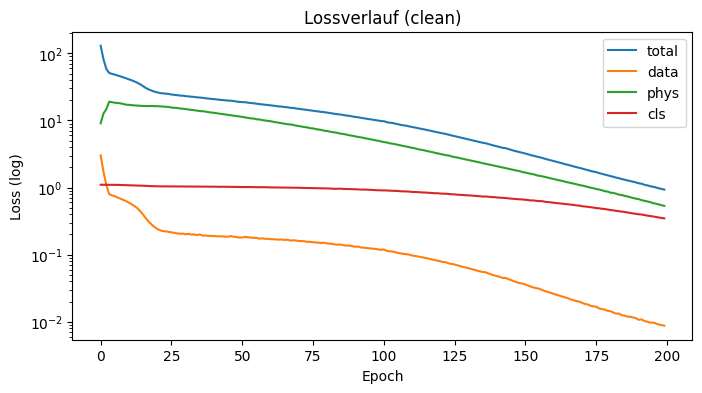

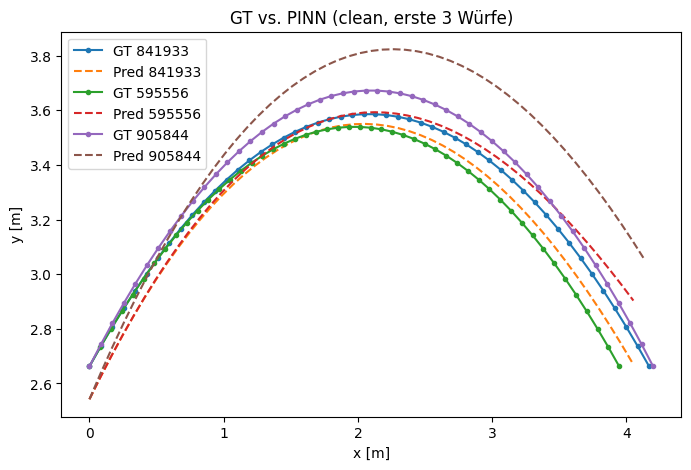

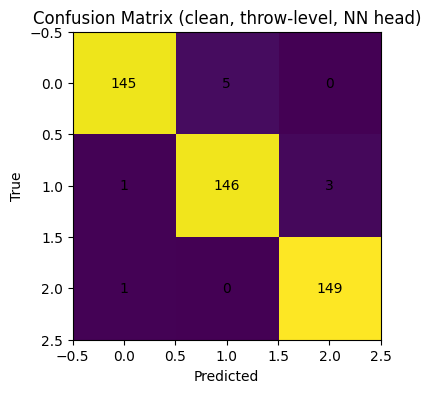

In [ ]:
device = "cpu"
dg = DataGen()
df_clean = dg.generate_dataset(with_noise=False)

wurf_ids = df_clean["wurf_id"].unique()
np.random.shuffle(wurf_ids)

split = int(0.8 * len(wurf_ids))
train_ids = set(wurf_ids[:split])
test_ids = set(wurf_ids[split:])

df_train = df_clean[df_clean["wurf_id"].isin(train_ids)].copy()
df_test = df_clean[df_clean["wurf_id"].isin(test_ids)].copy()

# scales
x_scale = dg.params["l"]
y_scale = 3.5  # kannst du auch dynamisch wählen; wichtig nur konsistent
y0_norm = dg.wurf_hoehe / y_scale

n_obs = 30
train_ds = TrajDataset(
    df_train, n_obs=n_obs, mode="clean", x_scale=x_scale, y_scale=y_scale
)
test_ds = TrajDataset(
    df_test, n_obs=n_obs, mode="clean", x_scale=x_scale, y_scale=y_scale
)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

model = PINNModel(n_obs=n_obs, z_dim=16, y0_norm=y0_norm, n_classes=3).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)



## Noisy‑Training (Trajektorie) → Wurfklassifikation aus Vorhersage

Epoch 001 | loss=1.345437e+02 (data=3.142421e+00, phys=8.663847e+00, cls=1.140077e+00)
Epoch 002 | loss=8.532104e+01 (data=1.838126e+00, phys=1.161455e+01, cls=1.108530e+00)
Epoch 003 | loss=5.969903e+01 (data=1.121576e+00, phys=1.465187e+01, cls=1.107069e+00)
Epoch 004 | loss=5.236314e+01 (data=8.300659e-01, phys=1.897483e+01, cls=1.102963e+00)
Epoch 005 | loss=5.080155e+01 (data=8.029158e-01, phys=1.849948e+01, cls=1.098301e+00)
Epoch 020 | loss=2.965055e+01 (data=3.411949e-01, phys=1.579335e+01, cls=1.078491e+00)
Epoch 040 | loss=2.188993e+01 (data=2.100462e-01, phys=1.323966e+01, cls=1.044460e+00)
Epoch 060 | loss=1.798197e+01 (data=1.909561e-01, phys=1.007716e+01, cls=1.013971e+00)
Epoch 080 | loss=1.445294e+01 (data=1.701755e-01, phys=7.389870e+00, cls=9.732824e-01)
Epoch 100 | loss=1.119205e+01 (data=1.443040e-01, phys=5.192703e+00, cls=9.177262e-01)
Epoch 120 | loss=8.073521e+00 (data=1.062643e-01, phys=3.635495e+00, cls=8.019494e-01)
Epoch 140 | loss=5.345021e+00 (data=6.54033

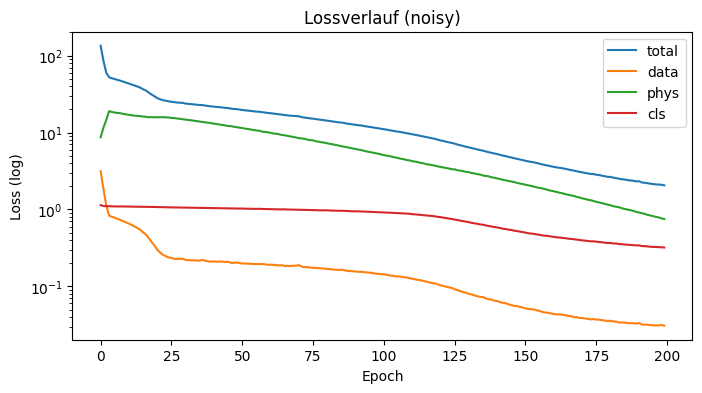

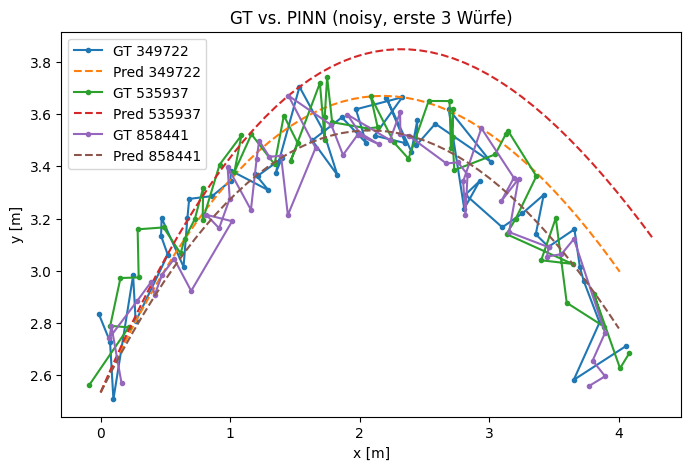

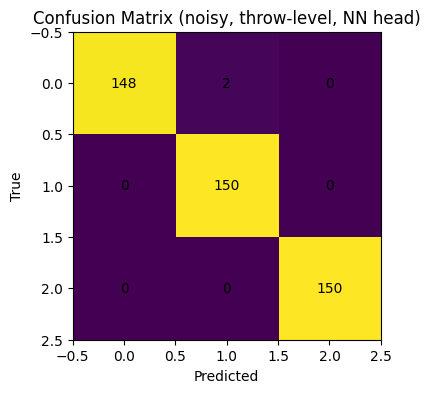

In [ ]:
df_noisy = sim.generate_dataset(n=150, with_noise=True)
num_throws_clean = df_noisy["wurf_id"].nunique()
model_noisy = FreeThrowPINNModel(
    num_throws=df_noisy["wurf_id"].nunique(),
    hidden_dim=64,
    n_hidden_layers=3,
    n_classes=3,
)

model_noisy, hist_noisy, dproc_noisy = train_pinn(
    model_noisy,
    df_noisy,
    n_epochs=200,
    batch_size=1024,
    lr=1e-3,
    lambda_data=40.0,
    lambda_phys=1.0,
    lambda_cls=0.1,
    n_collocation_per_sample=5,
    device=device,
)

plt.figure(figsize=(8, 4))
plt.plot(hist_noisy["loss"], label="total")
plt.plot(hist_noisy["data_loss"], label="data")
plt.plot(hist_noisy["phys_loss"], label="phys")
plt.plot(hist_noisy["cls_loss"], label="cls")  # NEW
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss (log)")
plt.legend()
plt.title("Lossverlauf (noisy)")


pred_noisy = predict_xy(model_noisy, dproc_noisy)
ids = pred_noisy["wurf_id"].unique()[:3]
plt.figure(figsize=(8, 5))
for wid in ids:
    g_gt = dproc_noisy[dproc_noisy["wurf_id"] == wid].sort_values("t")
    g_pr = pred_noisy[pred_noisy["wurf_id"] == wid].sort_values("t")
    plt.plot(g_gt["x"], g_gt["y"], marker=".", label=f"GT {wid[:6]}")
    plt.plot(g_pr["x_pred"], g_pr["y_pred"], linestyle="--", label=f"Pred {wid[:6]}")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("GT vs. PINN (noisy, erste 3 Würfe)")
plt.legend()

eval_noisy = evaluate_throw_level_nn(dproc_noisy, model_noisy, device=device)

print("Clean throw-level metrics (NN head):")
print(
    "Accuracy=",
    eval_noisy["acc"],
    " Precision=",
    eval_noisy["prec"],
    " Recall=",
    eval_noisy["rec"],
    " F1=",
    eval_noisy["f1"],
)

cm_noisy = eval_noisy["cm"]
plt.figure(figsize=(5, 4))
plt.imshow(cm_noisy)
plt.title("Confusion Matrix (noisy, throw-level, NN head)")
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(cm_noisy.shape[0]):
    for j in range(cm_noisy.shape[1]):
        plt.text(j, i, cm_noisy[i, j], ha="center", va="center")

In [ ]:
def add_point_index(df: pd.DataFrame) -> pd.DataFrame:
    """Fügt pro wurf_id einen 1-basierten Punktindex hinzu (nach Zeit sortiert)."""
    assert "wurf_id" in df.columns, "Erwarte Spalte 'wurf_id'."
    if "t" in df.columns:
        df = df.sort_values(["wurf_id", "t"]).copy()
    else:
        df = df.sort_values(["wurf_id"]).copy()
    df["point_idx"] = df.groupby("wurf_id").cumcount() + 1
    return df


def split_first30_full50(
    df: pd.DataFrame, first_n: int = 30
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Gibt (df_train30, df_full50) zurück.
    df_train30 enthält nur die ersten N Punkte pro Wurf.
    df_full50 enthält alle verfügbaren Punkte (typisch 50).
    """
    dfi = add_point_index(df)
    df_train30 = dfi[dfi["point_idx"] <= first_n].copy()
    df_full50 = dfi.copy()
    return df_train30, df_full50

In [ ]:
def plot_trajectories_with_cutoff(
    pred_full50_df: pd.DataFrame, wurf_ids=None, max_plots: int = 3
):
    """
    Plottet für ausgewählte Würfe die GT- und Pred-Trajektorie (x,y) und markiert den Cutoff bei point_idx=30.
    """
    if wurf_ids is None:
        wurf_ids = list(pred_full50_df["wurf_id"].unique())[:max_plots]

    for wid in wurf_ids[:max_plots]:
        dfw = pred_full50_df[pred_full50_df["wurf_id"] == wid].sort_values("point_idx")
        cutoff_x = (
            dfw.loc[dfw["point_idx"] == 30, "x"].iloc[0]
            if (dfw["point_idx"] == 30).any()
            else None
        )

        plt.figure(figsize=(5.5, 4.5))
        plt.plot(dfw["x"], dfw["y"], label="GT")
        plt.plot(dfw["x_pred"], dfw["y_pred"], label="Pred")
        if cutoff_x is not None:
            plt.axvline(cutoff_x, linestyle="--", label="Cutoff @ 30")
        plt.title(f"Wurf {wid}: GT vs. Pred (1–50)")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.legend()
        plt.tight_layout()
        plt.show()

Epoch 001 | loss=2.678927e+01 (data=1.203410e+00, phys=2.377144e+00, cls=1.122246e+00)
Epoch 002 | loss=2.185653e+01 (data=8.303494e-01, phys=4.896851e+00, cls=1.101717e+00)
Epoch 003 | loss=1.915852e+01 (data=7.571220e-01, phys=3.653221e+00, cls=1.101333e+00)
Epoch 004 | loss=1.716795e+01 (data=5.881179e-01, phys=5.033232e+00, cls=1.098562e+00)
Epoch 005 | loss=1.620132e+01 (data=5.044549e-01, phys=5.731396e+00, cls=1.097261e+00)
Epoch 020 | loss=1.235175e+01 (data=3.310751e-01, phys=5.221350e+00, cls=1.052621e+00)
Epoch 040 | loss=9.379858e+00 (data=2.158753e-01, phys=4.461307e+00, cls=1.044674e+00)
Epoch 060 | loss=7.799209e+00 (data=1.760768e-01, phys=3.702338e+00, cls=1.027665e+00)
Epoch 080 | loss=6.446389e+00 (data=1.458383e-01, phys=3.025910e+00, cls=1.009385e+00)
Epoch 100 | loss=5.238743e+00 (data=1.194865e-01, phys=2.424838e+00, cls=9.706351e-01)
Epoch 120 | loss=4.178286e+00 (data=9.555454e-02, phys=1.916495e+00, cls=9.152602e-01)
Epoch 140 | loss=3.247436e+00 (data=7.41685

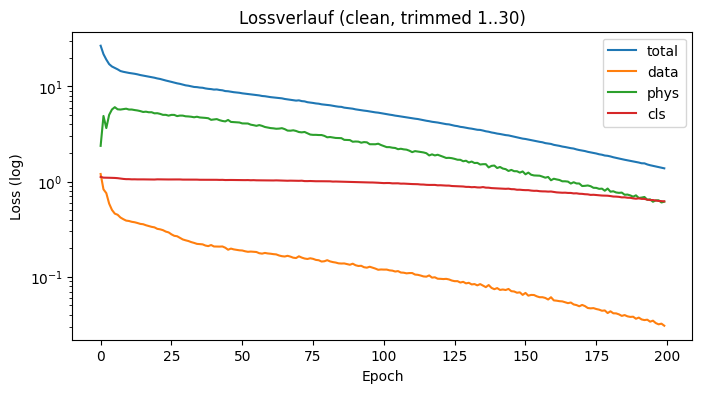

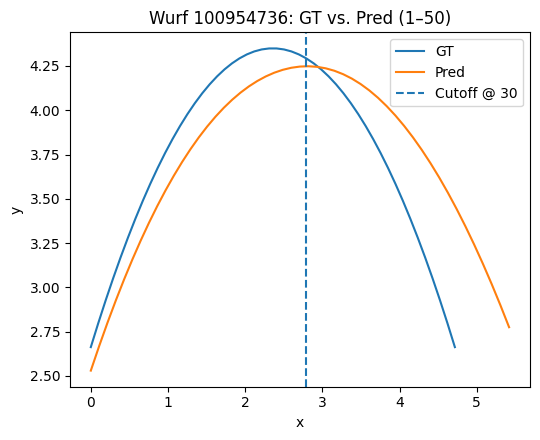

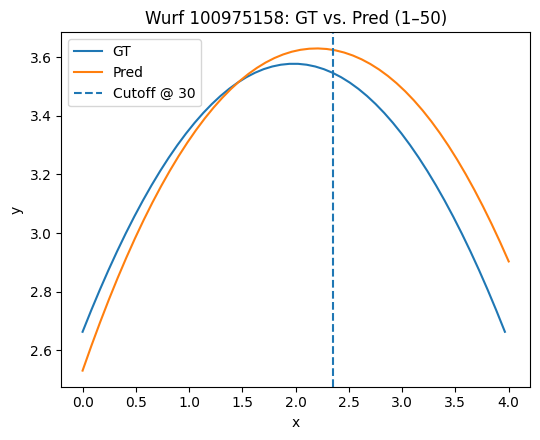

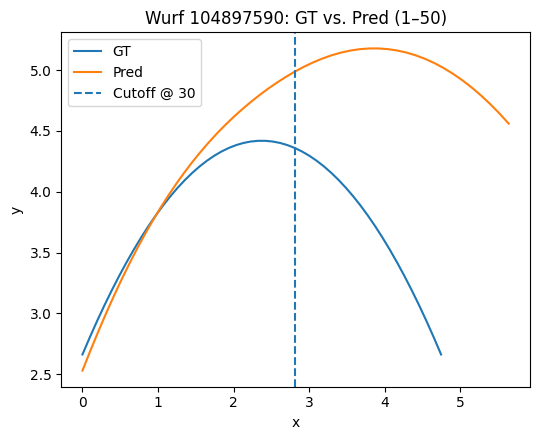

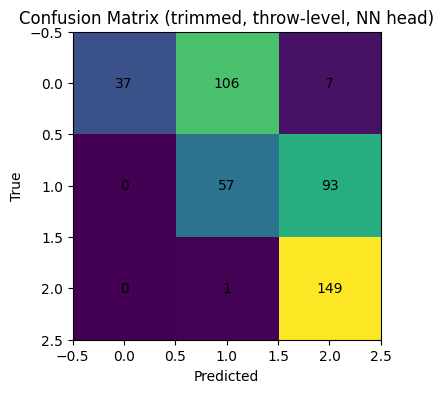

In [48]:
df_clean2 = sim.generate_dataset(n=150, with_noise=False)
df_train30_clean, df_full50_clean = split_first30_full50(df_clean2, first_n=30)

num_throws_trimmed = df_train30_clean["wurf_id"].nunique()
model_clean2 = FreeThrowPINNModel(
    num_throws=num_throws_trimmed,
    hidden_dim=64,
    n_hidden_layers=3,
    n_classes=3,
)

model_clean2, hist_clean_trim, dproc_trimmed = train_pinn(
    model_clean2,
    df_train30_clean,
    n_epochs=200,
    batch_size=1024,
    lr=1e-3,
    lambda_data=20.0,
    lambda_phys=1.0,
    lambda_cls=0.1,
    lambda_ic=5.0,
    n_collocation_per_sample=5,
    df_tmax_ref=df_full50_clean,  
    device=device,
)

# optional: Lossverlauf inkl. cls_loss plotten
plt.figure(figsize=(8, 4))
plt.plot(hist_clean_trim["loss"], label="total")
plt.plot(hist_clean_trim["data_loss"], label="data")
plt.plot(hist_clean_trim["phys_loss"], label="phys")
plt.plot(hist_clean_trim["cls_loss"], label="cls")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss (log)")
plt.legend()
plt.title("Lossverlauf (clean, trimmed 1..30)")

# 4) Vorhersage für ALLE 1–50 Punkte
pred_full50_clean = predict_xy(model_clean2, df_full50_clean)

eval_throw_clean = evaluate_throw_level_nn(df_full50_clean, model_clean2, device=device)

print("Trimmed throw-level metrics (NN head):")
print(
    "Accuracy=",
    eval_throw_clean["acc"],
    " Precision=",
    eval_throw_clean["prec"],
    " Recall=",
    eval_throw_clean["rec"],
    " F1=",
    eval_throw_clean["f1"],
)

print("CLEAN — Beispiele")
plot_trajectories_with_cutoff(pred_full50_clean, max_plots=3)

cmn = eval_throw_clean["cm"]
plt.figure(figsize=(5, 4))
plt.imshow(cmn)
plt.title("Confusion Matrix (trimmed, throw-level, NN head)")
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(cmn.shape[0]):
    for j in range(cmn.shape[1]):
        plt.text(j, i, cmn[i, j], ha="center", va="center")